In [1]:
import librosa
import numpy as np
import librosa.display
from pathlib import Path
import IPython.display as ipd
import matplotlib.pyplot as plt

In [2]:
NEY_DIR = "dataset/ney/"
GTR_DIR = "dataset/ac_gtr/"

In [3]:
ney_files = sorted([NEY_DIR + f.name for f in Path(NEY_DIR).rglob("*.wav")])
gtr_files = sorted([GTR_DIR + f.name for f in Path(GTR_DIR).rglob("*.wav")])

In [4]:
print(ney_files[0])
print(gtr_files[0])

dataset/ney/00_Ney_C_3.wav
dataset/ac_gtr/00_Gtr_C_3.wav


In [5]:
SR = 48000

In [6]:
ipd.Audio(ney_files[0], rate=SR)

In [11]:
signal, _ = librosa.load(ney_files[0], mono=True, sr=SR)
print(signal.shape)

(102000,)


In [12]:
FRAME_SIZE = 2048
HOP_LENGTH = 512

In [13]:
stft = librosa.stft(signal, n_fft=FRAME_SIZE, hop_length=HOP_LENGTH)
print(stft.shape)

(1025, 200)


In [14]:
power = np.abs(stft) ** 2
db = librosa.power_to_db(power)

In [15]:
def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(
        Y,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis)

    plt.colorbar(format="%+2.f")

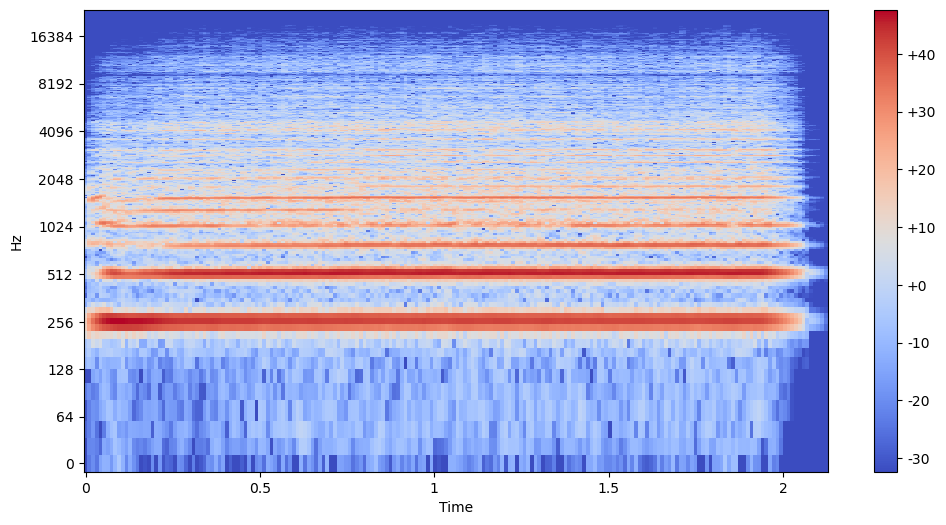

In [16]:
plot_spectrogram(db, SR, HOP_LENGTH, y_axis="log")